#### Imports

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DATA_FILE, TARGET_COLUMN
from src.data_loader import load_energy_dataset, parse_datetime_column
from src.eda_utils import (
    summarize_dataset,
    summarize_missing_values,
    plot_target_over_time,
    plot_correlation_heatmap,
    plot_boxplots_for_selected_columns,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

#### Load data

In [4]:
# Load raw dataset
energy_df = load_energy_dataset("E:\Vectorium Labs\energy-forecast\dataset\energy_data_set.csv")

# Parse datetime and sort chronologically
energy_df = parse_datetime_column(energy_df, datetime_column="date", set_as_index=True)

# Preview dataset
summarize_dataset(energy_df)

Shape: (19735, 28)

Data types:
 Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

First 5 rows:
                      Appliances  lights     T1       RH_1    T2       RH_2  \
date                                                                         
2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
2016-01-11 17:10:00          60      30  19.89  46.693333  

In [12]:
energy_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


#### Basic Inspection

In [5]:
# Display statistical summary for numeric columns
energy_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


#### Missing values

In [6]:
# Check missing values
missing_summary_df = summarize_missing_values(energy_df)
missing_summary_df

,missing_count,missing_percentage
Appliances,0,0.0
lights,0,0.0
T1,0,0.0
RH_1,0,0.0
T2,0,0.0
RH_2,0,0.0
T3,0,0.0
RH_3,0,0.0
T4,0,0.0
RH_4,0,0.0


#### Target trend over time

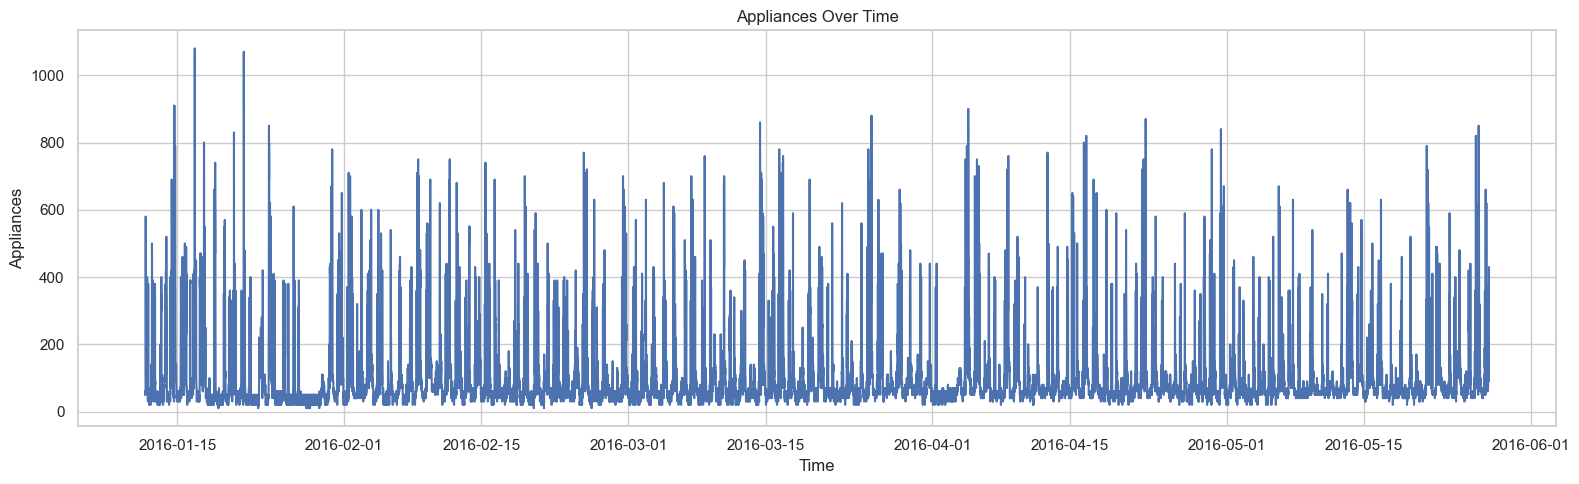

In [7]:
# Visualize target behavior over time
plot_target_over_time(energy_df, target_column=TARGET_COLUMN)

#### Correlation heatmap

In [1]:
# Explore linear relationships between numeric variables
plot_correlation_heatmap(energy_df)

NameError: name 'plot_correlation_heatmap' is not defined

#### Boxplots

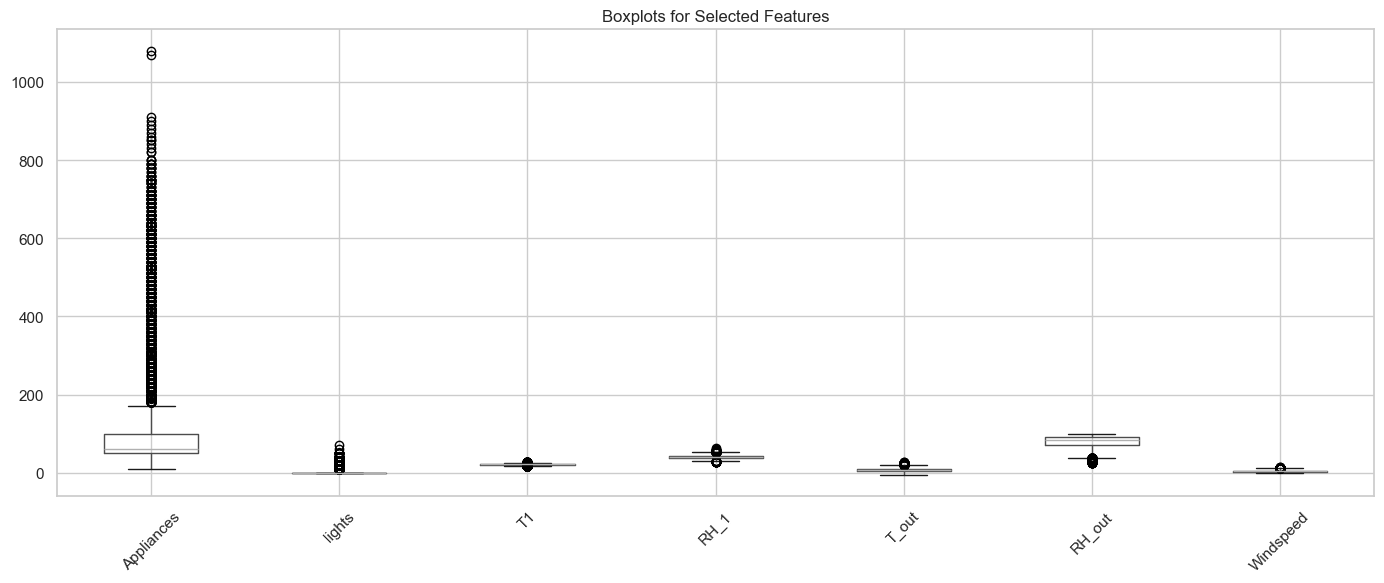

In [10]:
selected_columns = [
    "Appliances",
    "lights",
    "T1",
    "RH_1",
    "T_out",
    "RH_out",
    "Windspeed",
]

plot_boxplots_for_selected_columns(energy_df, selected_columns)

#### Hourly pattern

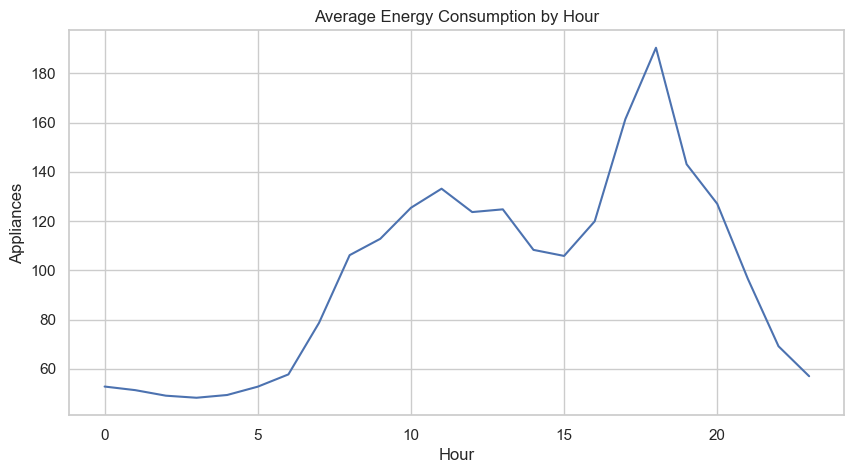

In [13]:
# Extract hour from datetime index
energy_df['hour'] = energy_df.index.hour

# Compute average per hour
hourly_avg = energy_df.groupby('hour')['Appliances'].mean()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Appliances")
plt.show()

#### Distribution plot

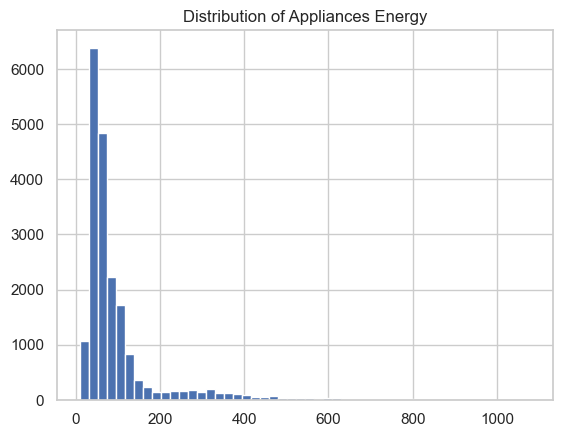

In [14]:
energy_df['Appliances'].hist(bins=50)
plt.title("Distribution of Appliances Energy")
plt.show()